# Processing Sentinel-1 TOPS interferogram with ISCE3 & COMPASS.

**Authors**: Zhenli Tang, Zhang Yunjun

**Learning Goals**:
* Understand unique features of Sentinel-1 SAR data (TOPS mode)
* ISCE3 & COMPASS generates InSAR products for Sentinel-1 SLCs
* Understand the numerous processing steps needed to generate a geocoded interferogram
* Visualize intermediate and final results

**Estimated time**: 2 hours + exercises

---

## 1. Introduction & Background


### 1.1 Background on TOPS Mode

The TOPS acquisition strategy is different than conventional stripmap mode.
The first satellite to use TOPS mode operationally was Sentinel-1.
TOPS stands for Terrain Observation with Progressive Scans. As the name
indicates, the radar sensor performs a scan of the surface by electronically
steering the antenna beam from a backward-pointing along-track direction to a
forward-pointing along-track direction for a fixed range swath (also called a
subswath).

![TOPS mode](docs/tops_mode.png)

After a successful scan at that range extent, the antenna beam is electronically
rolled back to its initial position, the range swath is electronically directed
outward to a new area to increase coverage, and the next scan is made from
backward to forward along track at this new range swath. After a third scan
at a third range swath, the entire process is repeated to create a continuous
image as the satellite flies along. The timing of the scans is such that there
is a small geographic overlap between successive scans at a given range to
ensure continuous coverage. Each scan at a given range swath is known as a
"burst". When inspecting one of the downloaded SLC products you will note that
data are provided in 3 individual subswaths (IW1, IW2, IW3) each with a set of
bursts. All together they form a Sentinel-1 frame, typically ~250 x 250 km in
size. The bursts are approximately 20 km in length and overlap by 2 km. Due to
the TOPS acquisition mode, the overlap region in successive bursts is seen from
two different directions (forward looking and backward looking).

![TOPS bursts](docs/tops.png)

![Burst ID naming convention](docs/burst_id_convention.png)  
The burst index is computed from orbital timing parameters
(ESA Sentinel-1 Level 1 Detailed Algorithm Definition, §9):

$$\Delta t_b = t_b - t_{anx} + (r - 1) T_{orb}$$

$$\text{burst\_index} = 1 + \left\lfloor \frac{\Delta t_b - T_{pre}}{T_{beam}} \right\rfloor$$

| Symbol | Value | Description |
|:-------|:-----:|:------------|
| $t_b$ | — | Mid-burst sensing time (IW2 midpoint) |
| $t_{anx}$ | — | Ascending node crossing time |
| $r$ | 1–175 | Relative orbit (track) number |
| $T_{orb}$ | $12 \times 86400 / 175 \approx 5924.57$ s | Nominal orbital period |
| $T_{pre}$ | 2.299849 s (IW) | Preamble length |
| $T_{beam}$ | 2.758273 s (IW) | Beam cycle time (one burst interval) |

The ESA website provides detailed background information on Sentinel-1 products
and technical information of the TOPS sensors:
https://sentinel.esa.int/web/sentinel/user-guides/sentinel-1-sar  
https://sentiwiki.copernicus.eu/web/s1-documents


### 1.2 Dependencies


| Category | Package | Purpose |
|:---------|:--------|:--------|
| **Core Processing** | `isce3` | InSAR processing engine |
| | `COMPASS` | COregistered Multi-temPorAl Sar Slc — CSLC geocoding & ionospheric TEC download |
| | `snaphu-py` | Phase unwrapping (SNAPHU) |
| **Data Preparation** | `burst_db` | Burst/frame database generation |
| | `burst2safe` | Burst download & SAFE conversion |
| | `eof` | Orbit file download |
| | `sardem` | DEM download |
| **Visualisation** | `matplotlib` | Plotting (imshow, colorbars, subplots) |
| **Utilities** | `psutil` | Memory usage monitoring |


## 2. Setup & Study Area


### 2.1 Study Area

Kilauea Volcano, Hawaii Island. The satellite image below shows the
coverage of six Sentinel-1 bursts (IW2 & IW3) over the summit caldera region.
The study area focuses on the Kilauea summit caldera region where all six bursts overlap.

![Burst Coverage and Study Area](docs/satellite_bbox.png)


### 2.2 Environment & Imports


In [1]:
# === Standard library ===
import gc
import os
import sys
from pathlib import Path

# === Third-party ===
import h5py
import isce3
import numpy as np
import tarfile
import zipfile
from datetime import datetime
from urllib.request import urlretrieve
from osgeo import gdal
from compass.utils.iono import download_ionex
from scipy.ndimage import uniform_filter
from matplotlib import pyplot as plt

# === Local imports ===
import utils as ut

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
work_dir = Path('~/data/HawaiiSenA124').expanduser()
work_dir.mkdir(parents=True, exist_ok=True)
process_dir = work_dir / 'process'

ref_date  = '2024-09-15'
sec_date  = '2024-10-09'
ref_ymd   = ref_date.replace('-', '')
sec_ymd   = sec_date.replace('-', '')
name_prefix = f'{ref_ymd}_{sec_ymd}'

bbox_wsen = (-155.50, 19.13, -154.95, 19.55)

# ---------------------------------------------------------------------------
# Ensure ! commands find the conda environment's executables
# ---------------------------------------------------------------------------
os.environ['PATH'] = os.pathsep.join([
    os.path.dirname(sys.executable),
    os.environ.get('PATH', ''),
])

# ---------------------------------------------------------------------------
# Start-up
# ---------------------------------------------------------------------------
plt.rcParams.update({'font.size': 8})

# Clear memory from any previous run
gc.collect()

print(f"""
{'='*60}
  InSAR Processing — Hawaii Big Island
  Reference : {ref_date}
  Secondary : {sec_date}
  AOI       : {bbox_wsen}
  Workspace : {work_dir}
  isce3     : {isce3.__version__}
  GDAL      : {gdal.__version__}
{'='*60}
""")


  InSAR Processing — Hawaii Big Island
  Reference : 2024-09-15
  Secondary : 2024-10-09
  AOI       : (-155.5, 19.13, -154.95, 19.55)
  Workspace : /home/tangzhenli/data/HawaiiSenA124
  isce3     : 0.26.0-dev+2919e1c97
  GDAL      : 3.11.4



## 3. Prepare Burst .SAFE Files


### 3.0 Burst Database

In [ ]:
# ---- Burst database ----
# Option A: download pre-packaged burst-db tarball and extract
# Option B (fallback): download ESA burst DB sqlite3 then build locally
db_dir = work_dir / 'burst-db'
db_dir.mkdir(parents=True, exist_ok=True)
os.chdir(db_dir)
print('Working directory:', Path.cwd())
# Define the essential files that indicate a complete burst-db
required_files = [
    'opera-burst-bbox-only.sqlite3',
    'burst_map_IW_000001_375887.sqlite3',
]
db_ready = all((db_dir / f).exists() for f in required_files)
if not db_ready:
    # --- Option A: download pre-built tarball from Zenodo ---
    BURST_DB_URL = 'https://zenodo.org/records/21451844/files/hawaii_burst_db.tar.xz?download=1'
    tarball = db_dir / 'burst-db.tar.xz'
    
    try:
        print('Downloading burst-db tarball from Zenodo...')
        urlretrieve(BURST_DB_URL, tarball)
        print('Extracting...')
        with tarfile.open(tarball, 'r:xz') as tf:
            tf.extractall(db_dir, filter='data')
        tarball.unlink(missing_ok=True)
        print('Burst-db extracted successfully.')
    except Exception as e:
        print(f'Failed to download/extract tarball: {e}')
        print('Falling back to Option B...')
        # --- Option B: download ESA DB and build locally ---
        esa_db = db_dir / 'burst_map_IW_000001_375887.sqlite3'
        if not esa_db.exists():
            ESA_DB_URL = 'https://sar-mpc.eu/files/S1_burstid_20220530.zip'
            print(f'Downloading ESA burst DB from {ESA_DB_URL}...')
            esa_db_zip = db_dir / 'S1_burstid_20220530.zip'
            urlretrieve(ESA_DB_URL, esa_db_zip)
            
            with zipfile.ZipFile(esa_db_zip, 'r') as zf:
                zf.extract('S1_burstid_20220530/burst_map_IW_000001_375887.sqlite3', db_dir)
            esa_db_zip.unlink(missing_ok=True)
            print('ESA burst DB downloaded and extracted.')
        else:
            print(f'{esa_db} already exists, skipping download.')
        
        print('Building burst database (this may take a while)...')
        
        !opera-db create --esa-db-path {esa_db}
        print('Burst database built.')
else:
    print('Burst database already ready, skipping.')


Working directory: /scratch/tangzhenli/data/topsStack/hawaii/earthscope/burst-db
Burst database already ready, skipping.


### 3.1 Download Bursts

In [ ]:
(process_dir / 'SLCs').mkdir(parents=True, exist_ok=True)
os.chdir(process_dir / 'SLCs')

extent1 = "-155.45 19.20 -154.95 19.55"
extent2 = "-155.45 19.25 -154.95 19.55"
!burst2stack --rel-orbit 124 --all-anns --pols VV --swaths IW2 --start-date {ref_date} --end-date {ref_date} --extent {extent1}
!burst2stack --rel-orbit 124 --all-anns --pols VV --swaths IW2 --start-date {sec_date} --end-date {sec_date} --extent {extent1}
!burst2stack --rel-orbit 124 --all-anns --pols VV --swaths IW3 --start-date {ref_date} --end-date {ref_date} --extent {extent2}
!burst2stack --rel-orbit 124 --all-anns --pols VV --swaths IW3 --start-date {sec_date} --end-date {sec_date} --extent {extent2}


Found 3 burst(s), comprising 1 SAFE(s).
Check burst group validities...
Download completed: 6319498/6319498 bytes
Download completed: 143081470/143081470 bytes
Download completed: 143081470/143081470 bytes
Download completed: 143081470/143081470 bytes
Download complete.
Creating SAFEs...
SAFEs created!
Found 3 burst(s), comprising 1 SAFE(s).
Check burst group validities...
Download completed: 6319539/6319539 bytes
Download completed: 143087494/143087494 bytes
Download completed: 143087494/143087494 bytes
Download completed: 143087494/143087494 bytes
Download complete.
Creating SAFEs...
SAFEs created!


### 3.2 Download Orbits

In [3]:
(process_dir / 'Orbits').mkdir(parents=True, exist_ok=True)
os.chdir(process_dir)
!eof --search-path ./SLCs --save-dir ./Orbits --force-asf

[07/10 20:01:16] [INFO download.py] Skipping ./SLCs/S1A_IW_SLC__1SSV_20241009T043113_20241009T043118_056021_06DA10_59F0, already have EOF file
[07/10 20:01:16] [INFO download.py] Skipping ./SLCs/S1A_IW_SLC__1SSV_20240915T043110_20240915T043118_055671_06CC42_930A, already have EOF file
[07/10 20:01:16] [INFO download.py] Skipping ./SLCs/S1A_IW_SLC__1SSV_20240915T043112_20240915T043117_055671_06CC42_F57F, already have EOF file
[07/10 20:01:16] [INFO download.py] Skipping ./SLCs/S1A_IW_SLC__1SSV_20241009T043111_20241009T043119_056021_06DA10_396E, already have EOF file
[07/10 20:01:16] [INFO download.py] No Sentinel products found in directory ./SLCs, exiting


### 3.3 Download DEM

In [8]:
(process_dir / 'DEM').mkdir(parents=True, exist_ok=True)
os.chdir(process_dir)
!sardem --bbox -157 18 -154 21 --output-type float32 --output-format GTiff --data-source COP -o ./DEM/dem.tif

# Download NASADEM water-body mask alongside DEM
ut.download_nasadem_water_mask((-157, 18, -154, 21), process_dir / 'DEM')


[07/10 20:10:03] [INFO dem.py] Bounds: -157.0 18.0 -154.0 21.0
[07/10 20:10:03] [INFO cop_dem.py] Creating ./DEM/dem.tif
[07/10 20:10:03] [INFO cop_dem.py] Fetching remote tiles...
[07/10 20:10:03] [INFO cop_dem.py] Running GDAL command:
[07/10 20:10:03] [INFO cop_dem.py] gdalwarp /vsicurl/https://raw.githubusercontent.com/scottstanie/sardem/master/sardem/data/cop_global.vrt ./DEM/dem.tif -of GTiff -ot Float32 -te -157 18 -154 21 -tr 0.000277777777777777778 0.000277777777777777778 -s_srs "epsg:4326+3855" -t_srs "epsg:4326" -wo NUM_THREADS=4 -r nearest -wm 5000 -multi
Creating output file that is 10800P x 10800L.
]9;4;1;20.                                                   - estimated remaining time: 00:11:0]9;4;1;50..                                                  - estimated remaining time: 00:05:2]9;4;1;70...                                                 - estimated remaining time: 00:03:3]9;4;1;100...10                                               - estimated remaining 

### 3.4 Download TEC Files

In [ ]:
# ---- Download TEC (ionospheric) files before CSLC processing ----
# Uses COMPASS v0.5.7+ compass.utils.iono.download_ionex() which
# handles CDDIS archive, IONEX formats, gzip decompression.
# Added in v0.5.7: product_type (FINAL/RAPID), interval (02H).
tec_dir = process_dir / 'TEC'
tec_dir.mkdir(parents=True, exist_ok=True)

for date in (ref_date, sec_date):
    date_str = datetime.strptime(date, '%Y-%m-%d').strftime('%Y%m%d')
    try:
        tec_file = download_ionex(date_str, str(tec_dir),
                                  sol_code='jpl',
                                  product_type='FINAL',
                                  interval='02H')
        print(f'  {date}: {Path(tec_file).name}')
    except Exception as e:
        print(f'  {date}: TEC download failed ({e}); correction will be skipped.')

print('TEC download complete.')


journal: Got response 200. Resource exists at: https://cddis.nasa.gov/archive/gnss/products/ionex/2024/259/JPL0OPSFIN_20242590000_01D_02H_GIM.INX.gz
journal: Got response 200. Resource exists at: https://cddis.nasa.gov/archive/gnss/products/ionex/2024/259/JPL0OPSFIN_20242590000_01D_02H_GIM.INX.gz
journal: Downloading https://cddis.nasa.gov/archive/gnss/products/ionex/2024/259/JPL0OPSFIN_20242590000_01D_02H_GIM.INX.gz to /home/tangzhenli/data/HawaiiSenA124/process/TEC/JPL0OPSFIN_20242590000_01D_02H_GIM.INX.gz
journal: Downloaded IONEX file: /home/tangzhenli/data/HawaiiSenA124/process/TEC/JPL0OPSFIN_20242590000_01D_02H_GIM.INX.gz
journal: Execute command: gzip --force --decompress /home/tangzhenli/data/HawaiiSenA124/process/TEC/JPL0OPSFIN_20242590000_01D_02H_GIM.INX.gz
  2024-09-15: JPL0OPSFIN_20242590000_01D_02H_GIM.INX
journal: Got response 200. Resource exists at: https://cddis.nasa.gov/archive/gnss/products/ionex/2024/283/JPL0OPSFIN_20242830000_01D_02H_GIM.INX.gz
journal: Got respons

## 4. Burst Coregistration

### 4.1 Initialize Run Configuration

Like ISCE2's `topsApp.py` (whose inputs are set through an XML file), the
COMPASS CSLC workflow is driven by a run-configuration **YAML** file. Below is
the *complete* initial configuration written for each burst/date — every group
is shown explicitly rather than relying on hidden defaults. The template
mirrors the COMPASS defaults
([`s1_cslc_geo.yaml`](https://github.com/opera-adt/COMPASS/blob/main/src/compass/defaults/s1_cslc_geo.yaml))
and conforms to the validation schema
([`s1_cslc_geo_schemas.yaml`](https://github.com/opera-adt/COMPASS/blob/main/src/compass/schemas/s1_cslc_geo.yaml)).

```yaml
runconfig:
  name: cslc_s1_workflow_default
  groups:
    pge_name_group:
      pge_name: CSLC_S1_PGE
    input_file_group:
      safe_file_path:      # [SAFE file for this date]
      orbit_file_path:     # [orbit (EOF) file covering this date]
      burst_id:            # [burst ID, e.g. t124_264305_iw2]
    dynamic_ancillary_file_group:
      dem_file:            # DEM GeoTIFF
      dem_description: DEM description was not provided.
      tec_file:            # IONEX TEC file (optional; omitted if absent)
    static_ancillary_file_group:
      burst_database_file: # burst-db SQLite3
    product_path_group:
      product_path: .
      scratch_path: ./scratch
      sas_output_file:     # output HDF5 filename
      product_version: '0.2'
      product_specification_version: '0.1'
    primary_executable:
      product_type: CSLC_S1
    processing:
      polarization: co-pol
      geocoding:
        flatten: true
        x_posting: 5
        y_posting: 10
      geo2rdr:
        lines_per_block: 1000
        threshold: 1.0e-08
        numiter: 25
      correction_luts:
        enabled: true
        range_spacing: 120
        azimuth_spacing: 0.028
        troposphere:
          delay_type: wet_dry
      rdr2geo:
        threshold: 1.0e-08
        numiter: 25
        lines_per_block: 1000
        extraiter: 10
        compute_latitude: false
        compute_longitude: false
        compute_height: false
        compute_layover_shadow_mask: true
        compute_local_incidence_angle: true
        compute_ground_to_sat_east: true
        compute_ground_to_sat_north: true
    worker:
      internet_access: false
      gpu_enabled: false
      gpu_id: 0
    quality_assurance:
      browse_image:
        enabled: true
        complex_to_real: amplitude
        percent_low: 0
        percent_high: 95
        gamma: 0.5
        equalize: false
      perform_qa: true
      output_to_json: false
    output:
      cslc_data_type: complex64_zero_mantissa
      compression_enabled: true
      compression_level: 4
      chunk_size: [128, 128]
      shuffle: true
```

The `ut.write_geo_runconfig()` helper writes this YAML for each burst/date;
input paths are resolved automatically by `ut.find_burst_inputs()`.


Scan the downloaded SAFE directories to automatically populate
`burst_id_list` and `date_list` from annotation metadata.

In [2]:
slc_dir = process_dir / 'SLCs'
burst_id_list, date_list = ut.discover_burst_ids(slc_dir, [ref_ymd, sec_ymd])

# Reorder bursts: group by IW (iw2, iw3), burst_index asc within each IW,
# so 5.2 stitching follows the correct along-track laydown order.
burst_id_list = sorted(burst_id_list, key=lambda b: (b.split('_')[-1], int(b.split('_')[1])))
print(f'Found {len(burst_id_list)} burst(s) from {len(set(date_list))} date(s):')
for bid, dt in zip(burst_id_list, date_list):
    print(f'  {bid}  ({dt})')
print(f'\nburst_id_list = {burst_id_list}')
print(f'bbox_wsen = {bbox_wsen}')


Found 6 burst(s) from 1 date(s):
  t124_264304_iw2  (2024-09-15)
  t124_264305_iw2  (2024-09-15)
  t124_264306_iw2  (2024-09-15)
  t124_264304_iw3  (2024-09-15)
  t124_264305_iw3  (2024-09-15)
  t124_264306_iw3  (2024-09-15)

burst_id_list = ['t124_264304_iw2', 't124_264305_iw2', 't124_264306_iw2', 't124_264304_iw3', 't124_264305_iw3', 't124_264306_iw3']
bbox_wsen = (-155.5, 19.13, -154.95, 19.55)


In [3]:
# Resolve input paths and write one run-config YAML per burst/date
os.chdir(work_dir)
config_dir = process_dir / 'configs'
config_dir.mkdir(parents=True, exist_ok=True)

slc_dir = process_dir / 'SLCs'                               # SAFE files
orbit_dir = process_dir / 'Orbits'                                 # orbit (EOF) files
dem_file = process_dir / 'DEM' / 'dem.tif'                         # DEM GeoTIFF
burst_db = work_dir / 'burst-db' / 'opera-burst-bbox-only.sqlite3'
tec_dir = process_dir / 'TEC'                               # TEC files

for ymd in (ref_ymd, sec_ymd):
    for burst_id in burst_id_list:
        safe_path, orbit_path, tec_path = ut.find_burst_inputs(
            ymd, slc_dir, orbit_dir, tec_dir, burst_id=burst_id)
        cfg_out = config_dir / f'geo_runconfig_{ymd}_{burst_id}.yaml'
        ut.write_geo_runconfig(
            cfg_out, safe_path, orbit_path, burst_id,
            dem_file, burst_db, tec_file=tec_path)
        print(f'Wrote {cfg_out.name}')


Wrote geo_runconfig_20240915_t124_264304_iw2.yaml
Wrote geo_runconfig_20240915_t124_264305_iw2.yaml
Wrote geo_runconfig_20240915_t124_264306_iw2.yaml
Wrote geo_runconfig_20240915_t124_264304_iw3.yaml
Wrote geo_runconfig_20240915_t124_264305_iw3.yaml
Wrote geo_runconfig_20240915_t124_264306_iw3.yaml
Wrote geo_runconfig_20241009_t124_264304_iw2.yaml
Wrote geo_runconfig_20241009_t124_264305_iw2.yaml
Wrote geo_runconfig_20241009_t124_264306_iw2.yaml
Wrote geo_runconfig_20241009_t124_264304_iw3.yaml
Wrote geo_runconfig_20241009_t124_264305_iw3.yaml
Wrote geo_runconfig_20241009_t124_264306_iw3.yaml


### 4.2 Run CSLC Geocoding

Geocode each burst to a common UTM grid (5 m x 10 m spacing).

Output is OPERA-format HDF5 containing `VV`, `x_coordinates`,
`y_coordinates`, and `projection`.

In [6]:
# ---- 4.2 CSLC geocoding ----
# Run s1_cslc.py --grid geo for every burst×date combination,
# then generate date-independent static layers (layover/shadow mask,
# incidence angle, LOS vectors) for each unique burst.

(process_dir / 'logs').mkdir(parents=True, exist_ok=True)
cslc_dir = process_dir / 'CSLC'
cslc_dir.mkdir(parents=True, exist_ok=True)
os.chdir(cslc_dir)
# Build tasks: (burst_id, cfg_path, log_path) per burst×date
tasks = []
for dt, ymd in [(ref_date, ref_ymd), (sec_date, sec_ymd)]:
    for burst_id in burst_id_list:
        cfg = config_dir / f'geo_runconfig_{ymd}_{burst_id}.yaml'
        log = process_dir / 'logs' / f'{ymd}_{burst_id}.log'
        tasks.append((burst_id, cfg, log))

# Alternative: sequential (uncomment to run without multiprocessing)
# for burst_id, cfg, log in tasks:
#     with open(log, 'w') as lf:
#         rc = subprocess.run(['s1_cslc.py', '--grid', 'geo', str(cfg)],
#                             stdout=lf, stderr=subprocess.STDOUT).returncode
#         print(f'  {burst_id}: {"OK" if rc == 0 else f"FAILED ({rc})"}')

ut.run_s1_cslc_parallel(tasks)

CSLC processing (12 jobs, 4 workers)...


CSLC processing complete (12/12 succeeded).


12

Step to generate S1 Static layer Products if needed.

> ⏱ The following step generates **static layers** (layover/shadow mask, local incidence angle, LOS vectors) for each burst via COMPASS. This is **date-independent** (run once per burst) but **time-consuming** — each burst may take several minutes.
>
> **Recommended**: use ``ut.download_static_layers()`` in the next cell to download pre-computed CSLC-STATIC granules from ASF — this is much faster (typically < 1 min per burst vs. several minutes).  Falls back to local generation automatically.


In [3]:
# ---- 4.2a Static layers (one per burst, date-independent) ----
# Recommended: downloads pre-computed granules from ASF.
# Falls back to local COMPASS generation for any burst not on ASF.
cslc_dir = process_dir / 'CSLC'
cslc_dir.mkdir(parents=True, exist_ok=True)
os.chdir(cslc_dir)

downloaded = ut.download_static_layers(
    burst_id_list, process_dir, ref_ymd, bbox_wsen=bbox_wsen,
)

missing = [
    b for b in burst_id_list
    if not (cslc_dir / b / ref_ymd / f'static_layers_{b}.h5').exists()
]
if missing:
    print(f'\nGenerating remaining {len(missing)} bursts locally...')
    ut.generate_static_layers(missing, config_dir, process_dir, ref_ymd)
else:
    print('All static layers ready.')

Searching ASF for CSLC-STATIC products (6 bursts)...
  Found 16 unique STATIC granules
  t124_264304_iw2: exists, skip
  t124_264305_iw2: exists, skip
  t124_264306_iw2: exists, skip
  t124_264304_iw3: exists, skip
  t124_264305_iw3: exists, skip
  t124_264306_iw3: exists, skip

Static layers: 6/6 bursts ready
All static layers ready.


#### 4.2.1 GSLC Processing Principle

*Explanation of the geometric coregistration principle behind the CSLC-S1 workflow — to be completed.*

**HDF5 Dataset Layout**

The OPERA CSLC-S1 HDF5 file follows a hierarchical structure consisting of the root group (`/`) and four top-level groups:

| Group | Description |
|:------|:------------|
| `/` | Root group containing main data raster layers: `VV` (complex64), `azimuth_carrier_phase`, `flattening_phase`, and geographical information: `x_coordinates`, `y_coordinates`, `projection` |
| `/identification` | File-level metadata including burst ID, mission identifier, orbit/timing parameters, product version, and bounding polygon |
| `/metadata` | Processing metadata: `orbit` (state vectors), `calibration_information`, `noise_information`, `processing_information` (timing corrections, runconfig, parameters) |
| `/quality_assurance` | Per-dataset statistics (min, max, mean, standard deviation) for `VV` phase/power and each timing correction field |

**Key Datasets** (from `info_cslc.txt`):

| Dataset Path | Type | Dimensions | Description |
|:-------------|:-----|:-----------|:------------|
| `/data/VV` | complex64 | `n_y` × `n_x` | Geocoded single-look complex SAR image |
| `/data/azimuth_carrier_phase` | float64 | `n_y` × `n_x` | Azimuth carrier phase (rad) |
| `/data/flattening_phase` | float64 | `n_y` × `n_x` | Flattening phase (rad) |
| `/data/x_coordinates` | float64 | `n_x` | UTM easting (m) |
| `/data/y_coordinates` | float64 | `n_y` | UTM northing (m) |
| `/data/projection` | int32 | scalar | EPSG code of the UTM projection |
| `/metadata/orbit/position_x` | float64 | `n_sv` | Orbit state vector X position (m) |
| `/metadata/orbit/velocity_x` | float64 | `n_sv` | Orbit state vector X velocity (m/s) |
| `/metadata/processing_information/timing_corrections/slant_range` | float64 | `n_az` × `n_rg` | Slant-range LUT grid (m) |
| `/metadata/processing_information/timing_corrections/zero_doppler_time` | float64 | `n_az` × `n_rg` | Azimuth zero-Doppler time LUT grid (s) |
| `/metadata/processing_information/timing_corrections/bistatic_delay` | float64 | `n_az` × `n_rg` | Bistatic delay correction (s) |
| `/metadata/processing_information/timing_corrections/los_solid_earth_tides` | float64 | `n_az` × `n_rg` | Solid Earth tide correction in LOS (m) |
| `/metadata/processing_information/timing_corrections/los_ionospheric_delay` | float64 | `n_az` × `n_rg` | Ionospheric delay correction in LOS (m) |
| `/metadata/processing_information/timing_corrections/wet_los_troposphere_delay` | float64 | `n_az` × `n_rg` | Wet troposphere delay correction in LOS (m) |
| `/metadata/processing_information/timing_corrections/dry_los_troposphere_delay` | float64 | `n_az` × `n_rg` | Dry troposphere delay correction in LOS (m) |

#### 4.2.2 GSLC Coregistration Processing Flow

In [1]:
# Inspect a single burst: raw SAFE (rdr) vs. geocoded H5 (geo)
# Uses ut.extract_burst_slc() to extract only the matching burst
# from the multi-burst SAFE measurement TIFF.


demo_burst_id = burst_id_list[2]
demo_date = ref_date
demo_ymd  = ref_ymd

# --- Left: Raw SAFE burst in radar coordinates ---
safe_path, _, _ = ut.find_burst_inputs(
    demo_ymd, process_dir / 'SLCs', process_dir / 'Orbits', process_dir / 'TEC',
    burst_id=demo_burst_id)

rdr_slc = ut.extract_burst_slc(safe_path, demo_burst_id)
rdr_amp = np.abs(rdr_slc)
rdr_amp_db = 20 * np.log10(np.maximum(rdr_amp, 1e-6))
print(f'  Radar SLC shape: {rdr_slc.shape}')
ut.print_memory_usage('inspect: after radar read')
rdr_title = f'{demo_burst_id} ({demo_date})  radar coordinates'

# --- Right: Geocoded CSLC H5 amplitude ---
h5 = process_dir / 'CSLC' / demo_burst_id / demo_ymd / f'{demo_burst_id}_{demo_ymd}.h5'
with h5py.File(h5) as f:
    geo_slc = f['/data/VV'][:]
geo_amp = np.abs(geo_slc.astype(np.complex64))
geo_amp_db = 20 * np.log10(np.maximum(geo_amp, 1e-6))

# --- Side-by-side plot ---
ut.plot_amplitude_pair(
    rdr_amp_db[::5, ::5], geo_amp_db[::5, ::5],
    title1=rdr_title,
    title2=f'{demo_burst_id} ({demo_date})  geocoded (UTM)',
    ext1=ut.extent_pixel(rdr_amp_db.shape),
    ext2=ut.extent_pixel(geo_amp_db.shape),
    xlabel1='range samples', ylabel1='azimuth lines',
    xlabel2='UTM easting samples', ylabel2='UTM northing samples',
    suptitle='Raw SAFE (radar) vs Geocoded CSLC H5 (geo)')

ut.print_memory_usage('inspect: after radar+geo display')
del rdr_slc, rdr_amp, rdr_amp_db, geo_slc, geo_amp, geo_amp_db
ut.print_memory_usage('inspect: after cleanup')


NameError: name 'burst_id_list' is not defined

### 4.3 Auxiliary Information

CSLC geocoding involves two categories of operations:

- **Geo-registration** &mdash; six timing corrections improve the accuracy of
  the inverse map &rarr; radar coordinate mapping, so that each pixel is
  precisely located on the correct radar grid position;
- **Phase compensation** &mdash; deramping, reramping, and flattening
  operate on the complex SLC phase to remove the TOPS carrier and
  geometric phase while preserving deformation, atmosphere, and other
  geophysical signals.


The following table summarises the auxiliary datasets stored in the
CSLC HDF5 product.  Datasets are grouped into three categories:

- **Geometry** — orbit / DEM / systematic shifts
- **Physical** — atmosphere, tides, and other geophysical delays
- **Focusing** — TOPS-specific azimuth artefacts

`coreg`: used for pixel-alignment during geocoding.

`compensate`: applied as phase correction after geocoding.

All HDF5 paths are relative to the root group.

| Category | Dataset | Description | coreg | compensate | HDF5 Path |
|:---------|:--------|:------------|:-----:|:----------:|:----------|
| **geometry** | `geometry_steering_doppler` | Doppler range shift | ✓ | ✗ | `timing_corrections/` |
| | `bistatic_delay` | Bistatic azimuth timing offset | ✓ | ✗ | `timing_corrections/` |
| **physical** | `los_solid_earth_tides` | Solid Earth tide LOS displacement | ✓ | ✗ | `timing_corrections/` |
| | `azimuth_solid_earth_tides` | Solid Earth tide azimuth displacement | ✓ | ✗ | `timing_corrections/` |
| | `los_ionospheric_delay` | Ionospheric path delay (LOS) | ✓ | ✗ | `timing_corrections/` |
| | `wet_los_troposphere_delay` | Wet troposphere delay (LOS) | ✓ | ✗ | `timing_corrections/` |
| | `dry_los_troposphere_delay` | Dry troposphere delay (LOS) | ✓ | ✗ | `timing_corrections/` |
| **focusing** | `azimuth_fm_rate_mismatch` | TOPS azimuth FM rate mismatch | ✓ | ✗ | `timing_corrections/` |
| | `azimuth_carrier_phase` | TOPS deramp carrier phase | ✗ | ✓ | `/data/` |
| | `flattening_phase` | Topographic flattening phase | ✗ | ✓ | `/data/` |

All timing corrections are under
`/metadata/processing_information/timing_corrections/`.
The carrier phase and flattening phase are stored in `/data/`.
These corrections shift pixel positions during geocoding but do
**not** modify the SLC phase — atmospheric and tidal signals
remain as residual phase for downstream InSAR analysis.

#### 4.3.1 Geometry (DEM & Orbit Errors)

Geometric offsets arise from orbit errors and DEM height
inaccuracies.  These are systematic corrections derived from
the satellite orbit state vectors and the reference DEM, and
are applied as timing corrections during geocoding.

- **`geometry_steering_doppler`** &mdash; Doppler-induced range
  shift caused by antenna beam steering.  Units: *meters*.
- **`bistatic_delay`** &mdash; Azimuth timing offset between the
  true bistatic SAR geometry and the equivalent monostatic
  approximation.  Units: *seconds*.


  [before geom corrections] memory: 0.3 GB / 10 GB (3.1%)


Geometry corrections for t124_264306_iw2 (2024-09-15):
  geometry_steering_doppler — mean: 0.0005 m, std: 0.2507 m
  bistatic_delay            — mean: 0.000320 s, std: 0.000055 s


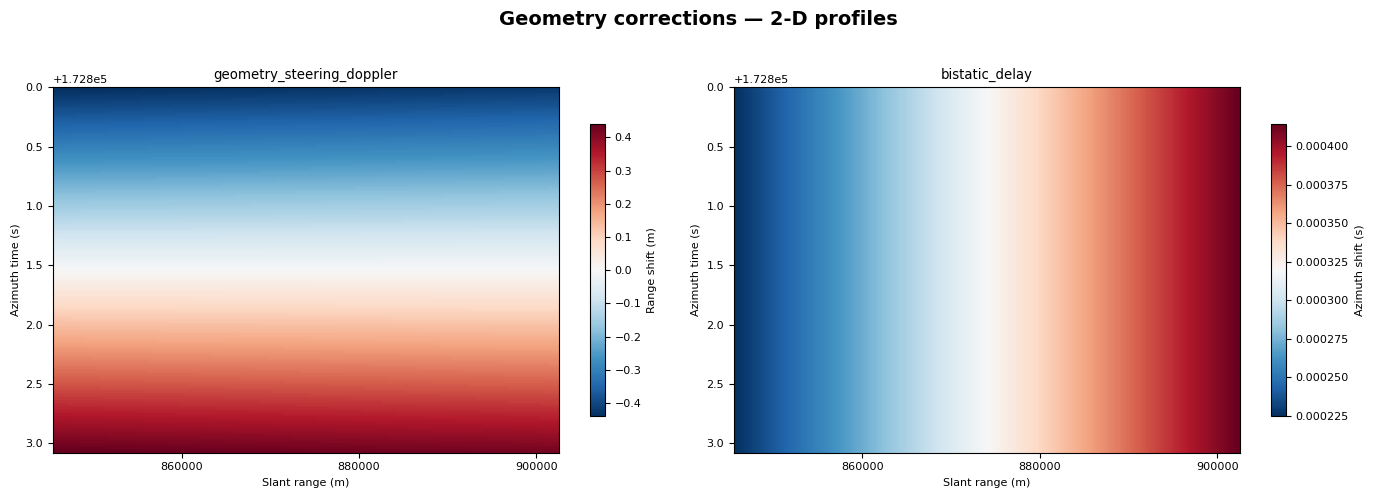

  [after geom corrections] memory: 0.3 GB / 10 GB (3.1%)


In [5]:
# ---- 4.3.1 Geometry: geometric correction datasets ----
ut.print_memory_usage('before geom corrections')
h5_path = process_dir / 'CSLC' / demo_burst_id / ref_ymd / f'{demo_burst_id}_{ref_ymd}.h5'
ut.plot_geom_corrections(h5_path, burst_id=demo_burst_id, date_str=ref_date)
plt.close('all')
ut.print_memory_usage('after geom corrections')


#### 4.3.2 Physical (Atmosphere & Tides)

Physical offsets arise from geophysical processes that delay
or advance the radar signal along the propagation path.

- **`los_solid_earth_tides`** — surface displacement from
  solid Earth tides along LOS.  Units: *meters*.
- **`los_ionospheric_delay`** — ionospheric phase advance
  converted to LOS range delay via TEC maps (1 TECU ≈ 0.014 m).
  Units: *meters*.
- **Static troposphere** — recomputed from COMPASS formula
  `ZPD / cos(inc) * exp(-h / H)`.  ZPD = 2.3 m (zenith path
  delay at sea level), H = 6000 m (scale height).  Incidence
  angle and height are derived from the real DEM + orbit
  geometry on the radar (LUT) grid.  Units: *meters*.

The static troposphere delay is **not** stored as a separate
dataset in the HDF5 product — it is merged into the cumulative
range correction LUT during geocoding.  The code below
reproduces it using the same formula as
`compass/utils/lut.py::compute_static_troposphere_delay()`.


  [before phys corrections] memory: 0.3 GB / 10 GB (3.1%)


Physical corrections for t124_264306_iw2 (2024-09-15):
  Solid Earth tide (LOS):      0.0879 m
  Solid Earth tide (azimuth):  0.0000 s
  Ionospheric delay (LOS):     1.6265 m
  Static troposphere (LOS):    2.5371 m
  Weather-model tropo:         0.0000 m


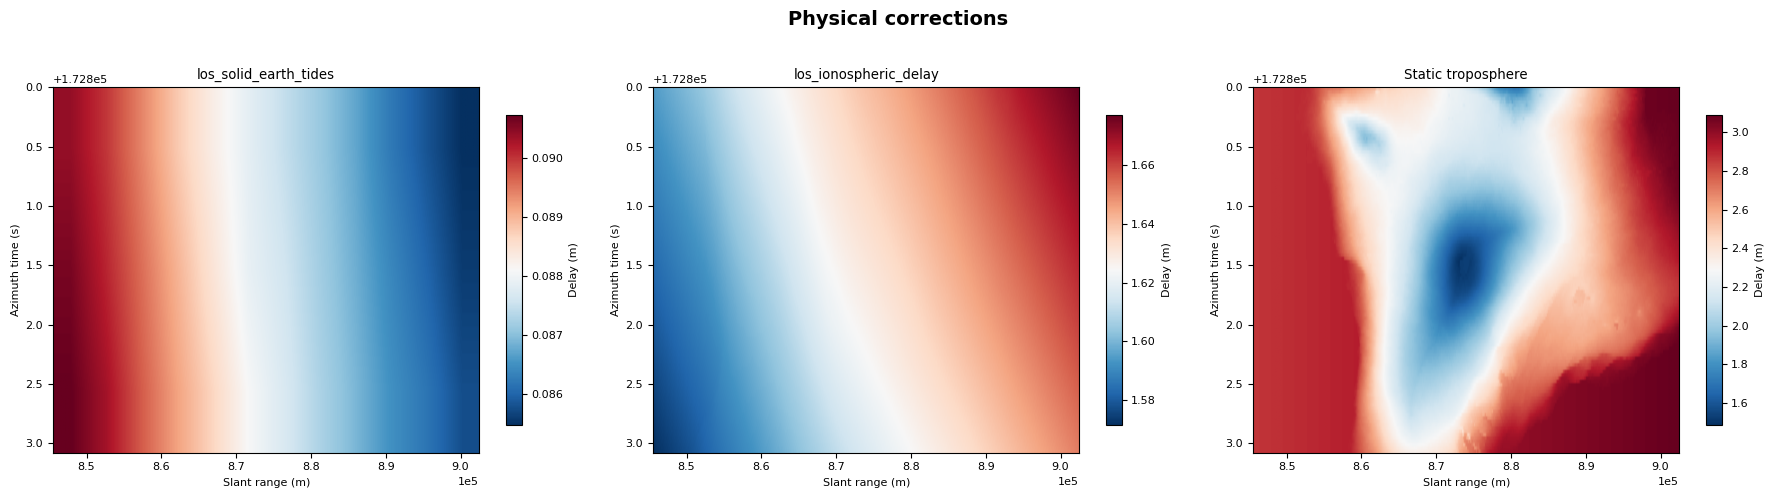

  [after phys corrections] memory: 0.4 GB / 10 GB (3.7%)


In [6]:
# ---- 4.3.2 Physical: atmosphere/tide correction datasets ----
ut.print_memory_usage('before phys corrections')
h5_path = process_dir / 'CSLC' / demo_burst_id / ref_ymd / f'{demo_burst_id}_{ref_ymd}.h5'
dem_path = process_dir / 'DEM' / 'dem.tif'
ut.plot_phys_corrections(h5_path, dem_path, burst_id=demo_burst_id, date_str=ref_date)
plt.close('all')
ut.print_memory_usage('after phys corrections')


#### 4.3.3 Focusing (S1 TOPS Scalloping)

Sentinel-1 IW mode uses **TOPS** — the antenna beam sweeps
from backward to forward along track within each burst.  This
introduces an azimuth-dependent Doppler centroid and FM rate
variation:

- **`azimuth_fm_rate_mismatch`** &mdash; Residual FM rate
  mismatch after azimuth compression.  Applied as an azimuth
  timing correction.  Units: *seconds*.
- **`azimuth_carrier_phase`** &mdash; The azimuth carrier phase
  polynomial used for TOPS deramp and demodulation.  This is a
  **phase compensation** term (not a timing correction).
  Units: *radians*.


  [before focus corrections] memory: 0.4 GB / 10 GB (3.7%)
Focusing corrections for t124_264306_iw2 (2024-09-15):
  FM rate mismatch:  mean=8.738270e-06 s, std=1.609094e-04 s


  Azimuth carrier phase: mean=0.01 rad, std=1.81 rad


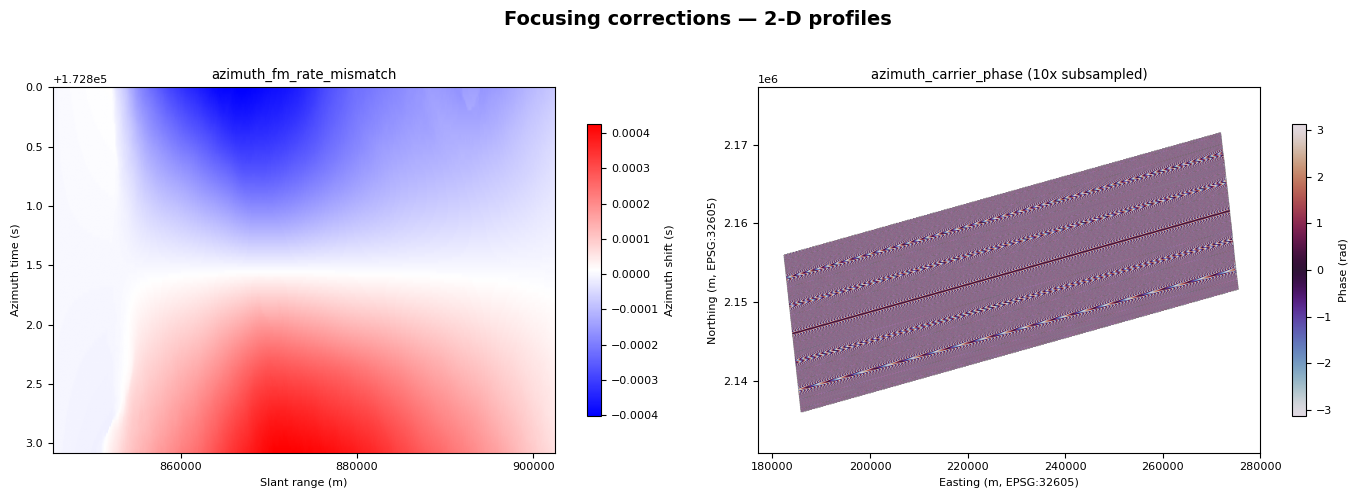

  [after focus corrections] memory: 0.3 GB / 10 GB (3.3%)


In [7]:
# ---- 4.3.3 Focusing: TOPS-specific correction datasets ----
ut.print_memory_usage('before focus corrections')
h5_path = process_dir / 'CSLC' / demo_burst_id / ref_ymd / f'{demo_burst_id}_{ref_ymd}.h5'
ut.plot_focus_corrections(h5_path, burst_id=demo_burst_id, date_str=ref_date)
plt.close('all')
ut.print_memory_usage('after focus corrections')


## 5. Per-burst Interferogram Formation & Processing

We form interferograms **per burst** before stitching.  This avoids
mixing data from different bursts (which have different TOPS azimuth
steering directions) during the sliding-window coherence computation.
The updated pipeline is:

1. **Per-burst interferogram** — cross-multiply ref×sec within each burst
2. **Stitch interferograms** — combine into a single continuous image
3. **Complex coherence** — sliding-window correlation on stitched SLCs
4. **Multilook + Goldstein filter** — reduce speckle, adaptive phase filter
5. **Phase-sigma coherence** — phase-stability measure for unwrapping
6. **SNAPHU unwrapping** — recover absolute phase


### 5.1 Per-burst Interferogram & Complex Coherence

Each burst pair is processed in a single pass:

1. **Collect extents** — read only coordinate vectors from every CSLC H5
   (cheap metadata, negligible memory), compute the union grid clipped
   to the study-area bounding box.
2. **Pre-allocate stitched arrays** — two zero-initialised arrays
   covering the full union extent: ``ifg_stitched`` (complex64) and
   ``coh_stitched`` (float32).
3. **Process one burst at a time** — for each burst:
   - Read the ref and sec CSLC arrays from disk.
   - Align, form interferogram, compute complex coherence.
   - Copy valid pixels into the pre-allocated stitched arrays via
     ``ut.blit_into_stitched()``.
   - Render the per-burst ifg/coh into a pre-created subplot grid.
   - Delete the burst-level arrays immediately.

This avoids accumulating per-burst arrays in a list, keeping peak
memory under the 10 GB limit.


  [mem cleared] memory: 0.2 GB / 10 GB (2.4%)
UTM EPSG: 32605 (consistent)
Union grid: 4725 rows x 11680 cols
  [before pre-allocation] memory: 0.2 GB / 10 GB (2.4%)
  [after pre-allocation] memory: 0.2 GB / 10 GB (2.4%)
  [t124_264304_iw2 after read] memory: 1.7 GB / 10 GB (17.1%)
  t124_264304_iw2: ifg (4659, 20592)  coh [0.000, 1.000]
  [t124_264305_iw2 after read] memory: 2.5 GB / 10 GB (25.2%)
  t124_264305_iw2: ifg (4656, 20592)  coh [0.000, 1.000]
  [t124_264306_iw2 after read] memory: 2.7 GB / 10 GB (27.3%)
  t124_264306_iw2: ifg (4653, 20592)  coh [0.000, 1.000]
  [t124_264304_iw3 after read] memory: 2.7 GB / 10 GB (27.3%)
  t124_264304_iw3: ifg (4605, 18552)  coh [0.000, 1.000]
  [t124_264305_iw3 after read] memory: 2.8 GB / 10 GB (27.7%)
  t124_264305_iw3: ifg (4602, 18558)  coh [0.000, 1.000]
  [t124_264306_iw3 after read] memory: 2.9 GB / 10 GB (28.6%)
  t124_264306_iw3: ifg (4599, 18552)  coh [0.000, 1.000]


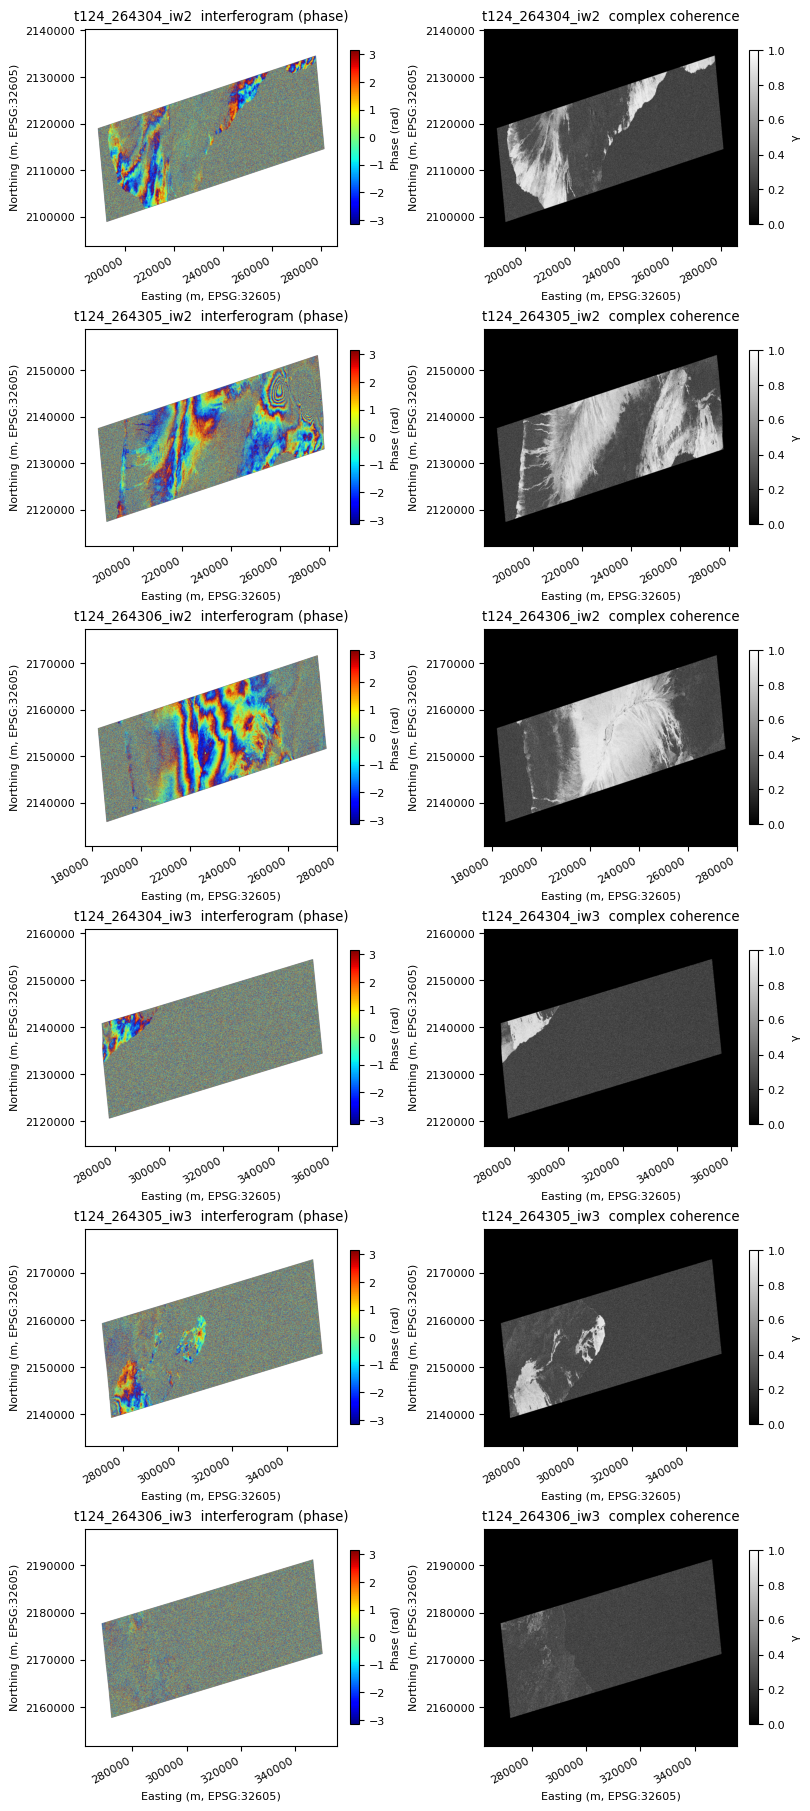

  [after per-burst processing] memory: 1.2 GB / 10 GB (11.9%)
Per-burst ifg/coh computed + stitched for 6 burst(s).


In [4]:
# ---- 5.1 Per-burst interferogram & complex coherence (pre-allocated) ----
ut.clear_large_arrays()

# Phase 1: collect extents (reads only x/y vectors — negligible memory)
extents = []
for burst_id in burst_id_list:
    ref_h5 = process_dir / 'CSLC' / burst_id / ref_ymd / f'{burst_id}_{ref_ymd}.h5'
    extents.append(ut.get_cslc_extent(ref_h5))

# Derive EPSG from extents (all bursts should share the same UTM zone)
epsgs = {e[6] for e in extents}                    # e[6] = epsg
if len(epsgs) > 1:
    from collections import Counter
    epsg_utm = Counter(e[6] for e in extents).most_common(1)[0][0]
    print(f'WARNING: bursts span multiple EPSG zones: {epsgs}')
    print(f'         Using majority zone EPSG:{epsg_utm}')
else:
    epsg_utm = extents[0][6]
print(f'UTM EPSG: {epsg_utm} ({"consistent" if len(epsgs)==1 else f"{len(epsgs)} zones"})')

# Compute union grid
out_gt, out_rows, out_cols, proj_wkt = ut.compute_union_grid(
    extents, bbox_wsen, epsg_utm=epsg_utm)
print(f'Union grid: {out_rows} rows x {out_cols} cols')
ut.print_memory_usage('before pre-allocation')

# Phase 2: pre-allocate stitched arrays
ifg_stitched = np.zeros((out_rows, out_cols), dtype=np.complex64)
coh_stitched = np.zeros((out_rows, out_cols), dtype=np.float32)
ut.print_memory_usage('after pre-allocation')

# Phase 3: process each burst — read → compute → blit → plot → delete
coh_win = 5
area = coh_win * coh_win
n_bursts = len(burst_id_list)

fig, axes = plt.subplots(n_bursts, 2, figsize=(8, 3 * n_bursts),
                         constrained_layout=True)
if n_bursts == 1:
    axes = axes[np.newaxis, :]

for i, burst_id in enumerate(burst_id_list):
    ref_h5 = process_dir / 'CSLC' / burst_id / ref_ymd / f'{burst_id}_{ref_ymd}.h5'
    sec_h5 = process_dir / 'CSLC' / burst_id / sec_ymd / f'{burst_id}_{sec_ymd}.h5'

    ref_arr, gt, _, _ = ut.read_cslc_array(ref_h5)
    sec_arr, sec_gt, _, _ = ut.read_cslc_array(sec_h5)
    ut.print_memory_usage(f'{burst_id} after read')

    # Align
    ref_arr, sec_arr, gt = ut.align_cslc_pair(ref_arr, gt, sec_arr, sec_gt)

    nodata = ~np.isfinite(ref_arr) | ~np.isfinite(sec_arr)
    ref_arr[nodata] = 0.0 + 0.0j
    sec_arr[nodata] = 0.0 + 0.0j

    # Interferogram
    ifg_burst = ref_arr * np.conj(sec_arr)

    # Complex coherence (5x5 sliding window)
    ref_pow = (np.abs(ref_arr) ** 2).astype(np.float32)
    sec_pow = (np.abs(sec_arr) ** 2).astype(np.float32)
    ifg_sum = uniform_filter(ifg_burst, size=coh_win, mode='constant') * area
    ref_sum = uniform_filter(ref_pow, size=coh_win, mode='constant') * area
    sec_sum = uniform_filter(sec_pow, size=coh_win, mode='constant') * area
    with np.errstate(invalid='ignore'):
        coh_burst = np.abs(ifg_sum) / np.sqrt(ref_sum * sec_sum)
    coh_burst = np.nan_to_num(coh_burst, nan=0.0).clip(0.0, 1.0).astype(np.float32)

    # Blit into stitched arrays
    ut.blit_into_stitched(ifg_stitched, out_gt, ifg_burst, gt)
    ut.blit_into_stitched(coh_stitched, out_gt, coh_burst, gt)

    # Plot per-burst results (UTM coordinates)
    extent = ut.extent_utm(gt, ifg_burst.shape)
    step = 5

    ph = np.ma.masked_where(np.abs(ifg_burst) < 1e-6, np.angle(ifg_burst))
    ut.plot_phase(axes[i, 0], ph[::step, ::step], extent=extent,
                  title=f'{burst_id}  interferogram (phase)')
    ut.set_ax_utm(axes[i, 0], epsg_utm)

    ut.plot_coherence(axes[i, 1], coh_burst[::step, ::step], extent=extent,
                      title=f'{burst_id}  complex coherence')
    ut.set_ax_utm(axes[i, 1], epsg_utm)

    # Report and cleanup
    valid = ~np.ma.masked_invalid(np.abs(ifg_burst)).mask
    lo = coh_burst[valid].min() if valid.any() else 0.0
    print(f'  {burst_id}: ifg {ifg_burst.shape}  coh [{lo:.3f}, {coh_burst.max():.3f}]')
    del ref_arr, sec_arr, ref_pow, sec_pow, ifg_sum, ref_sum, sec_sum, ifg_burst, coh_burst

del ph, nodata, extents

ut.show_and_close()
ut.print_memory_usage('after per-burst processing')
print(f'Per-burst ifg/coh computed + stitched for {n_bursts} burst(s).')


### 5.2 Show Stitched Interferogram & Coherence

The per-burst arrays were already copied into ``ifg_stitched`` and
``coh_stitched`` in section 5.1.  Below we display the combined result
and compute useful statistics.


Stitched shape: 4725 x 11680
Valid pixels:   53357149 (96.7%)


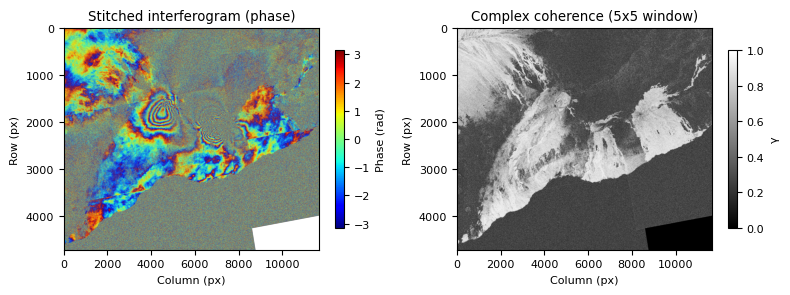

In [5]:
# ---- 5.2 Display stitched interferogram & coherence ----
ifg_gt = out_gt  # from compute_union_grid in 5.1
nz = np.sum(np.abs(ifg_stitched) > 0)
print(f'Stitched shape: {ifg_stitched.shape[0]} x {ifg_stitched.shape[1]}')
print(f'Valid pixels:   {nz} ({100*nz/ifg_stitched.size:.1f}%)')

# Define multilook factors for display subsampling
rglks = 4; azlks = 2

# --- Display (pixel coordinates to show image dimensions) ---
ph = np.ma.masked_where(np.abs(ifg_stitched) < 1e-6, np.angle(ifg_stitched))

ut.plot_ifg_coherence(
    ph[::azlks,::rglks], coh_stitched[::azlks,::rglks],
    phase_extent=ut.extent_pixel(ph.shape),
    coh_extent=ut.extent_pixel(coh_stitched.shape))


### 5.3 Multilooking & Goldstein Filter

Multilooked ifg:  (2362, 2920)
Multilooked coh:  (2362, 2920)
Goldstein filter (alpha=0.5, patch=32) ...


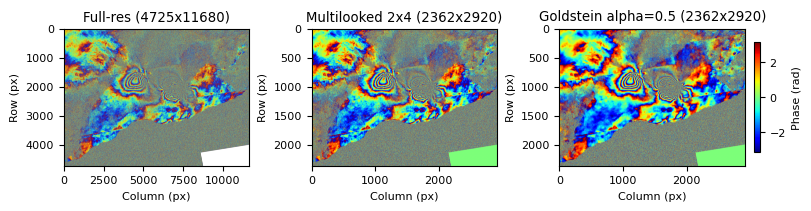

  [after ml+filter cleanup] memory: 1.0 GB / 10 GB (9.8%)


In [6]:
# ---- 5.3 Multilooking & Goldstein filter ----
rglks = 4; azlks = 2

# Multilook the stitched interferogram
ifg_ml = ut.multilook_ifg(ifg_stitched, az_looks=azlks, rg_looks=rglks)

# Multilook the stitched coherence (average over blocks)
coh_ml = ut.multilook_ifg(coh_stitched.astype(np.complex64),
                           az_looks=azlks, rg_looks=rglks)
coh_ml = np.abs(coh_ml).astype(np.float32)

print(f'Multilooked ifg:  {ifg_ml.shape}')
print(f'Multilooked coh:  {coh_ml.shape}')

# Goldstein filter
alpha = 0.5; psize = 32
nodata = np.abs(ifg_ml) < 1e-6
print(f'Goldstein filter (alpha={alpha}, patch={psize}) ...')
ifg_filt = ut.goldstein_filter(ifg_ml, alpha=alpha, psize=psize, nodata_mask=nodata)

# --- 3-panel display: full-res -> multilooked -> filtered ---
ph_ml = np.angle(ifg_ml)
ph_filt = np.angle(ifg_filt)
ut.plot_phase_triple(
    ph[::azlks,::rglks], ph_ml, ph_filt,
    title1=f'Full-res ({ifg_stitched.shape[0]}x{ifg_stitched.shape[1]})',
    title2=f'Multilooked {azlks}x{rglks} ({ifg_ml.shape[0]}x{ifg_ml.shape[1]})',
    title3=f'Goldstein alpha={alpha} ({ifg_filt.shape[0]}x{ifg_filt.shape[1]})',
    ext1=ut.extent_pixel(ph.shape))

# Free full-res arrays no longer needed
del ph, ifg_stitched, coh_ml, ifg_ml, nodata
ut.print_memory_usage('after ml+filter cleanup')


### 5.4 Phase-sigma Coherence

The interferometric phase is wrapped modulo $2\pi$.  Before
unwrapping with SNAPHU we estimate a **phase-sigma (phsig)**
coherence map that serves as a quality indicator.

**Phase-sigma algorithm**

1. Estimate local range and azimuth phase gradients via neighbour
   differencing and Gaussian convolution
2. Extract a local window around each pixel, subtract the gradient
   to deramp, compute weighted phase variance
3. Convert variance to correlation: $\gamma = 1/\sqrt{2 n_{lk} \sigma_\phi^2 + 1}$


Estimating phase-sigma coherence ...


Phsig  coherence range: [0.000, 1.000]
Complex coherence range: [0.000, 1.000]


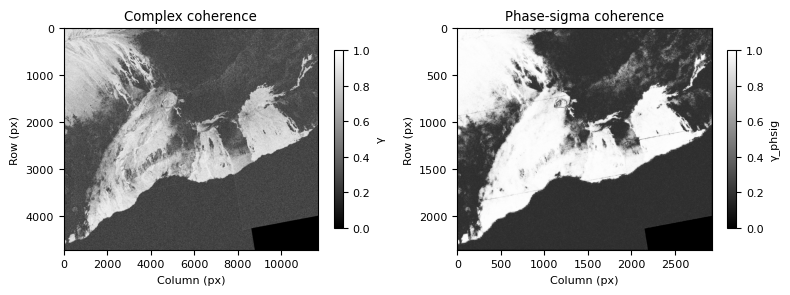

  [after coh_stitched cleanup] memory: 0.9 GB / 10 GB (9.1%)


In [7]:
# ---- 5.4 Phase-sigma coherence estimation ----
nlks = rglks * azlks
print('Estimating phase-sigma coherence ...')
phsig = ut.estimate_phsig_correlation(
    ifg_filt, ps_win=5, grad_win=5, nlks=nlks)

print(f'Phsig  coherence range: [{np.nanmin(phsig):.3f}, {np.nanmax(phsig):.3f}]')
print(f'Complex coherence range: [{np.nanmin(coh_stitched):.3f}, {np.nanmax(coh_stitched):.3f}]')

# --- Comparison: complex coherence vs phsig coherence ---
ut.plot_coherence_pair(
    coh_stitched[::azlks,::rglks], phsig,
    ext1=ut.extent_pixel(coh_stitched.shape))

del coh_stitched
ut.print_memory_usage('after coh_stitched cleanup')


### 5.5 Phase Unwrapping (SNAPHU)

In [8]:
# ---- 5.5 Phase unwrapping (SNAPHU) ----
from snaphu import unwrap

print(f'Unwrapping with SNAPHU (nlooks={nlks}, cost=smooth, init=mcf) ...')

# Load water mask on the multilooked grid for unwrapping
rglks = ut.DEFAULT_RANGE_LOOKS
azlks = ut.DEFAULT_AZIMUTH_LOOKS
gt_ml = (ifg_gt[0], ifg_gt[1] * rglks, 0.0,
         ifg_gt[3], 0.0, ifg_gt[5] * azlks)

water_mask = ut.load_water_mask(gt_ml, ifg_filt.shape, epsg_utm,
                                     wbd_dir=process_dir / 'DEM')
water_pct = 100 * water_mask.sum() / water_mask.size
print(f'Water mask: {water_pct:.1f}% of grid masked for unwrapping')

unw, conncomp = unwrap(igram=ifg_filt*(~water_mask), corr=phsig, nlooks=nlks,
                cost='smooth', init='mcf', nproc=1)

print(f'Unwrapped phase range: [{np.nanmin(unw):.2f}, {np.nanmax(unw):.2f}] rad')


Unwrapping with SNAPHU (nlooks=8, cost=smooth, init=mcf) ...


Water mask: 30.0% of grid masked for unwrapping

snaphu v2.0.7
22 parameters input from file /tmp/tmp2ojyjchf/snaphu.config.bodaj4ul.txt (22 lines total)
Reading wrapped phase from file /tmp/tmp2ojyjchf/snaphu.igram.uzwscz2o.c8
No weight file specified.  Assuming uniform weights
Reading correlation data from file /tmp/tmp2ojyjchf/snaphu.corr.0k2ihrcm.f4
Calculating smooth-solution cost parameters
Initializing flows with MCF algorithm
Running nonlinear network flow optimizer
Maximum flow on network: 8
Flow increment: 1  (Total improvements: 0)
Found 1 valid set(s) of connected nodes
Growing connected component mask
Writing connected components to file /tmp/tmp2ojyjchf/snaphu.conncomp.9lshjvm4.u4 as 4-byte unsigned ints
Maximum flow on network: 1
Total solution cost: 149649889
Integrating phase
Writing output to file /tmp/tmp2ojyjchf/snaphu.unw.yatbqop2.f4
Program snaphu done
Elapsed processor time:   0:07:05.39
Elapsed wall clock time:  0:07:05
Unwrapped phase range: [-95.50, 21.64] rad

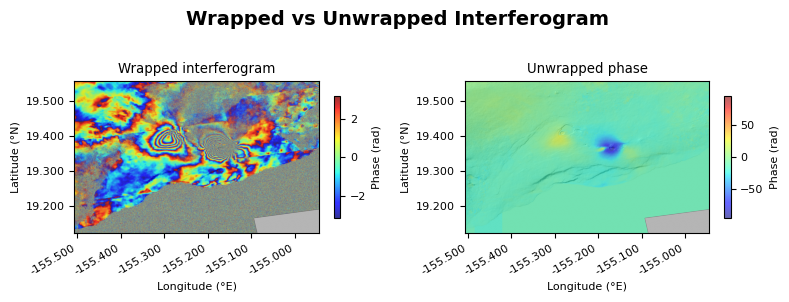

In [9]:
# --- Geotransform of the multilooked / filtered grid (UTM, EPSG:32605) ---
# ifg_filt was multilooked from ifg_stitched by (azlks x rglks).
gt_ml = (ifg_gt[0], ifg_gt[1] * rglks, 0.0,
         ifg_gt[3], 0.0, ifg_gt[5] * azlks)
nrow, ncol = unw.shape

# Compute EPSG:4326 extent from UTM geotransform
extent_deg = ut.extent_latlon(gt_ml, (nrow, ncol), epsg_utm)

# --- DEM background, warped onto the unwrapped grid ---
x0 = gt_ml[0]
x1 = gt_ml[0] + ncol * gt_ml[1]
y0 = gt_ml[3]
y1 = gt_ml[3] + nrow * gt_ml[5]
dem_src = str(process_dir / 'DEM' / 'dem.tif')
dem_ds = gdal.Warp('', dem_src, format='MEM',
                   dstSRS=f'EPSG:{epsg_utm}',
                   outputBounds=(x0, y1, x1, y0),   # (xmin, ymin, xmax, ymax)
                   width=ncol, height=nrow,
                   resampleAlg='bilinear')
dem = dem_ds.GetRasterBand(1).ReadAsArray().astype(np.float32)
dem_ds = None

# Simple hillshade for a shaded-relief backdrop
dy_grad, dx_grad = np.gradient(dem, np.abs(gt_ml[5]), np.abs(gt_ml[1]))
slope = np.pi / 2.0 - np.arctan(np.hypot(dx_grad, dy_grad))
aspect = np.arctan2(-dx_grad, dy_grad)
az, alt = np.deg2rad(315.0), np.deg2rad(45.0)
hillshade = (np.sin(alt) * np.sin(slope) +
             np.cos(alt) * np.cos(slope) * np.cos(az - aspect))

# --- Display: wrapped & unwrapped phase over DEM hillshade ---
wrapped = np.ma.masked_where(np.abs(ifg_filt) < 1e-6, np.angle(ifg_filt))
unw_m = np.ma.masked_where(np.abs(ifg_filt) < 1e-6, unw)
vm = np.nanmax(np.abs(unw_m))
ut.plot_phase_hillshade_pair(
    wrapped, unw_m, hillshade, extent_deg=extent_deg,
    title2='Unwrapped phase', alpha2=0.6,
    vmin2=-vm, vmax2=vm,
    suptitle='Wrapped vs Unwrapped Interferogram')
del dem, dx_grad, dy_grad, slope, aspect, hillshade, wrapped, unw_m


## 6. Save Processed Outputs

Save multilooked/filtered interferogram (phase), phase-sigma coherence,
unwrapped phase, and connected components to GeoTIFF files.


Computing LOS angles from static layers ...
  LOS: 2362 x 2920  epsg=32605
  [after los computation] memory: 2.5 GB / 10 GB (25.2%)


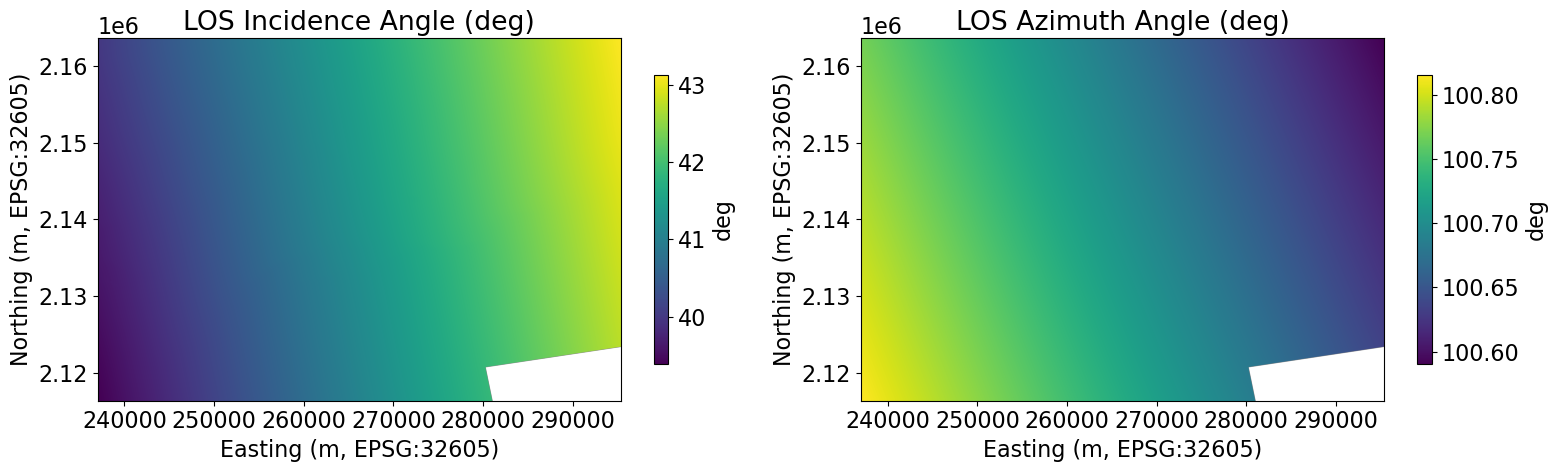

In [ ]:
# --- Compute LOS angles from static layers ---
print('Computing LOS angles from static layers ...')
inc_arr, az_arr, los_gt, los_epsg = ut.stitch_los_tiff(
    process_dir / 'CSLC', burst_id_list, ref_ymd,
    out_gt=gt_ml, out_shape=ifg_filt.shape,
    az_looks=azlks, rg_looks=rglks)
print(f'  LOS: {inc_arr.shape[0]} x {inc_arr.shape[1]}  epsg={los_epsg}')
ut.print_memory_usage('after los computation')

# --- Display LOS (mask zero-valued areas) in UTM coordinates ---
inc = np.ma.masked_where(inc_arr == 0, inc_arr)
az  = np.ma.masked_where(az_arr  == 0, az_arr)
extent = ut.extent_utm(gt_ml, inc_arr.shape)
ut.plot_los_pair(inc, az, extent=extent, epsg=los_epsg)
del inc, az


In [ ]:
# ---- 6. Save all processed outputs to GeoTIFF ----

output_dir = process_dir / 'interferograms' / name_prefix
output_dir.mkdir(parents=True, exist_ok=True)


# --- Save all products ---
products = {
    'filt_ml.int.tif':             (ifg_filt,           gt_ml, proj_wkt, gdal.GDT_CFloat32),
    'filt_ml.phsig.coh.tif':       (phsig,              gt_ml, proj_wkt, gdal.GDT_Float32),
    'filt_ml.unw.tif':             (unw,                gt_ml, proj_wkt, gdal.GDT_Float32),
    'filt_ml.unw.conncomp.tif':    (conncomp,           gt_ml, proj_wkt, gdal.GDT_Int32),
    'inc.tif':                     (inc_arr,            gt_ml, proj_wkt, gdal.GDT_Float32),
    'az.tif':                      (az_arr,             gt_ml, proj_wkt, gdal.GDT_Float32),
}

for fname, (data, geo, wkt, dtype) in products.items():
    path = output_dir / fname
    ut.save_tiff(path, data, geo, wkt, dtype=dtype)
    print(f'  Saved {fname}')

# Free arrays
del ifg_filt, phsig, unw, conncomp, inc_arr, az_arr, water_mask
ut.print_memory_usage('after all saves')

print(f'\nAll outputs saved to {output_dir}/')


  Saved filt_ml.int.tif
  Saved filt_ml.phsig.coh.tif
  Saved filt_ml.unw.tif
  Saved filt_ml.unw.conncomp.tif
  Saved los.tif
  [after all saves] memory: 2.6 GB / 10 GB (25.6%)

All outputs saved to /scratch/tangzhenli/data/topsStack/hawaii/earthscope/process/interferograms/20240915_20241009/


## 7. ionosphere correction

`to be edited`

In section 5.2, noticeable phase jumps can be observed at burst boundaries
in the stitched interferogram.  These phase discontinuities are caused by
**ionospheric effects** — spatial and temporal variations in the total
electron content (TEC) of the ionosphere introduce differential path delays
between the two acquisitions.

When ionospheric activity is low, these phase jumps become much less
pronounced.  The figure below shows an interferogram for the date pair
**2024-06-11 / 2024-06-23** where the ionosphere was relatively quiet:

![Interferogram 20240611_20240623](docs/intf.png)

Notice that the burst-boundary phase jumps are nearly absent in this
pair, confirming that the discontinuities seen in section 5.2 are
ionospheric in origin.


# Homework

## Interferogram of the 2020 M6.7 Elazığ Earthquake, Turkey

On 24 January 2020 at 20:55 UTC, an Mw 6.7 earthquake struck near the town of
Sivrice in Elazığ Province, eastern Turkey. The left-lateral strike-slip rupture
occurred along the Sivrice–Pütürge Segment of the East Anatolian Fault Zone
causing significant surface deformation. Detailed event information can be found
at the [USGS](https://earthquake.usgs.gov/earthquakes/eventpage/us60007ewc/executive)
report.

* **Setup**: Change section 2.2's `process_dir` from  
  `process_dir = work_dir / 'HawaiiSenA124'` to  
  `process_dir = work_dir / 'homework'` to isolate the exercise data.

* **Tip**: It is recommended to download **descending orbit** data to mitigate
ionospheric effects. Descending-orbit acquisitions occur during local evening/
early morning hours when ionospheric activity is typically lower, resulting in
fewer ionospheric artefacts such as azimuth streaks and phase jumps in the
interferogram.

# Appendix: OPERA CSLC-S1 Product Reference



## A.1 Product Overview

**OPERA_L2_CSLC-S1** (Coregistered Single-Look Complex from Sentinel-1)
is a Level-2 SAR product produced by the OPERA project at JPL/NASA
(*OPERA Project, [JPL](https://www.jpl.nasa.gov/go/opera/products/cslc-product-suite/), 2023*).
Each CSLC image contains amplitude and phase of the complex radar return,
coregistered and geocoded onto a common UTM grid.

| Property | Value |
|----------|-------|
| Product level | L2 (Level-2) |
| Format | HDF5 |
| Pixel type | complex64 |
| East posting | 5 m |
| North posting | 10 m |
| DAAC | ASF DAAC |
| Coverage | North America (US, US Territories, Canada within 200 km of US border, through Panama) |

**Applications:** InSAR time-series analysis, input for OPERA DISP-S1
displacement product, persistent/distributed scatterer processing,
coherence-based change detection.


## A.2 File Naming Convention

CSLC-S1 products follow the OPERA naming convention defined in the
*OPERA CSLC-S1 Product Specification* (D-108278, \u00a75.1):

```
OPERA_L2_CSLC-S1_<BURST-ID>_<ACQ-TIME>_<GEN-TIME>_<VERSION>.h5
```

| Segment | Format | Example |
|---------|--------|---------|
| `PROJECT` | `OPERA` | OPERA |
| `LEVEL` | `L2` | L2 |
| `PRODUCT-TYPE` | `CSLC-S1` | CSLC-S1 |
| `BURST-ID` | `tRRR_BBBBBB_iwN` | `t124_264305_iw2` |
| `ACQ-TIME` | `YYYYMMDDTHHMMSSZ` | `20240915T043110Z` |
| `GEN-TIME` | `YYYYMMDDTHHMMSSZ` | `20241001T120000Z` |
| `VERSION` | `vX.Y` | `v1.1` |

**Companion Product &mdash; CSLC-S1-STATIC**:
`OPERA_L2_CSLC-S1-STATIC` contains static radar geometry layers
(layover/shadow mask, local incidence angle, LOS vectors) generated
once per unique burst ID (*OPERA CSLC-S1 ATBD*, D-108752, \u00a73).
These layers are used in &sect; 6 to compute LOS incidence and azimuth
angles for the stitched interferogram.


## A.3 HDF5 Dataset Layout

The HDF5 file is organised into four groups (*CSLC-S1 Product
Specification*, D-108278, \u00a74):

**`/data/`** &mdash; primary data arrays:

| Dataset | Type | Dim | Description |
|---------|------|-----|-------------|
| `VV` | complex64 | (rows, cols) | Geocoded single-look complex SAR |
| `x_coordinates` | float64 | (cols,) | UTM easting (m) |
| `y_coordinates` | float64 | (rows,) | UTM northing (m) |
| `projection` | int32 | scalar | EPSG code |

**`/identification/`** &mdash; file-level metadata: burst ID, mission
identifier, orbit/timing, bounding polygon.

**`/metadata/processing_information/timing_corrections/`** &mdash;
correction LUT grids used in &sect; 4.3 (120 m ground spacing):

| Dataset | Description |
|---------|-------------|
| `slant_range` | Slant-range LUT (m) |
| `zero_doppler_time` | Zero-Doppler time LUT (s) |
| `bistatic_delay` | Bistatic delay (s) |
| `los_solid_earth_tides` | Solid Earth tide (m LOS) |
| `los_ionospheric_delay` | Ionospheric delay (m LOS) |
| `wet_los_troposphere_delay` | Wet troposphere (m LOS) |
| `dry_los_troposphere_delay` | Dry troposphere (m LOS) |

**`/quality_assurance/`** &mdash; per-dataset statistics: min, max,
mean, standard deviation.


# Relevant references:

- F. De Zan and A. Monti Guarnieri, "TOPSAR: Terrain Observation by Progressive Scans," in IEEE Transactions on Geoscience and Remote Sensing, vol. 44, no. 9, pp. 2352-2360, Sept. 2006, doi: 10.1109/TGRS.2006.873853.

- E. Sansosti, P. Berardino, M. Manunta, F. Serafino and G. Fornaro, "Geometrical SAR image registration," in IEEE Transactions on Geoscience and Remote Sensing, vol. 44, no. 10, pp. 2861-2870, Oct. 2006, doi: 10.1109/TGRS.2006.875787.

- C. Liang, P. Agram, M. Simons and E. J. Fielding, "Ionospheric Correction of InSAR Time Series Analysis of C-band Sentinel-1 TOPS Data," in IEEE Transactions on Geoscience and Remote Sensing, vol. 57, no. 9, pp. 6755-6773, Sept. 2019, doi: 10.1109/TGRS.2019.2908494.

- C. Gisinger et al., "In-Depth Verification of Sentinel-1 and TerraSAR-X Geolocation Accuracy Using the Australian Corner Reflector Array," in IEEE Transactions on Geoscience and Remote Sensing, vol. 59, no. 2, pp. 1154-1181, Feb. 2021, doi: 10.1109/TGRS.2019.2961248.

- Z. Yunjun et al., "Range Geolocation Accuracy of C-/L-Band SAR and its Implications for Operational Stack Coregistration," in IEEE Transactions on Geoscience and Remote Sensing, vol. 60, pp. 1-19, 2022, Art no. 5227219, doi: 10.1109/TGRS.2022.3168509.

- C. Gisinger et al., "The Extended Timing Annotation Dataset for Sentinel-1—Product Description and First Evaluation Results," in IEEE Transactions on Geoscience and Remote Sensing, vol. 60, pp. 1-22, 2022, Art no. 5232622, doi: 10.1109/TGRS.2022.3194216.

- Fattahi, H., "OPERA Coregistered Single Look Complex products from Sentinel-1 data", vol. 2022, Art. no. G45A-03, 2022.

- OPERA CSLC-S1 Product Specification, D-108278, v1.0, NASA JPL,
   2023.
   <https://d2pn8kiwq2w21t.cloudfront.net/documents/OPERA_CSLC-S1_ProductSpec_v1.0.0_D-108278_Initial_2023-09-11_URS321269.pdf>

- OPERA CSLC-S1 Algorithm Theoretical Basis Document (ATBD),
   D-108752, NASA JPL, 2024.

- OPERA CSLC-S1 Product Suite &mdash; JPL Operational Product
   Page.
   <https://www.jpl.nasa.gov/go/opera/products/cslc-product-suite/>

- ASF DAAC Data Search (OPERA-S1 dataset).
   <https://search.asf.alaska.edu/#/?dataset=OPERA-S1>